### **Figure 1.** Distributions of baseline age, sex and lag in the Cam-CAN MEG longitudinal sample. 

/home/mc06/Documents/CamCAN/code/camcan_meglongrest_specparamlme_2026/results
Main directory: /home/mc06/Documents/CamCAN/code/camcan_meglongrest_specparamlme_2026/data
{'Young': {'min_age': 24.3, 'max_age': 47.6, 'min_age_p5': 35.6, 'max_age_p5': 58.7, 'n_subjects': 45}, 'Middle': {'min_age': 47.8, 'max_age': 63.1, 'min_age_p5': 58.9, 'max_age_p5': 74.5, 'n_subjects': 44}, 'Old': {'min_age': 63.2, 'max_age': 84.1, 'min_age_p5': 70.9, 'max_age_p5': 95.5, 'n_subjects': 44}}


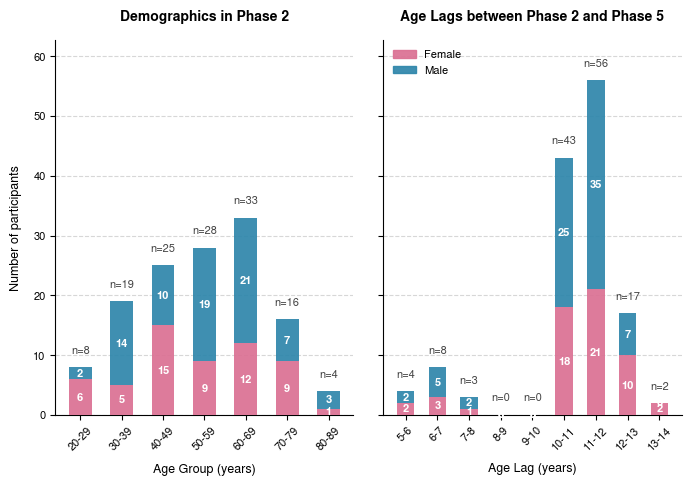

In [10]:
"""
Demographic Distribution of Baseline Age, Sex and Lag (Figure 1).

This notebook processes individual participant age and sex information from the 
Cam-CAN dataset to visualize the general characteristics of the cohort 
across distinct experimental phases.

Key Tracked Metrics:
- Phase 2 Age (Baseline age profile across the lifespan)
- Phase 5 Age (Follow-up age profile)
- Longitudinal Lag (The individual time step delta calculated between testing waves)
- Participant Sex (To confirm demographic distribution balance across cohorts)

Author: Maité Crespo García
Affiliation: MRC Cognition and Brain Sciences Unit, Cambridge, UK
Date: 2026 (last modified)
"""

import pandas as pd
import numpy as np
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import os
import sys
import warnings
warnings.filterwarnings('ignore')

#maindir = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
print(os.getcwd())
datadir = os.path.abspath(os.path.join(os.path.dirname( os.getcwd() ), '.', 'data'))
print(f'Main directory: {datadir}')
#datadir = '../data' #

task = 'rest'
phases = ['p2', 'p5']

# ---- File with subjects and arms ----
subjlistfile = os.path.join(datadir,f'meglong_{task}_subjects.tsv')

# ---- File with subjects and age in each phase ----
agefile = os.path.join(datadir,f'meglong_rest_age.tsv')

# --- File with sex information ---
filepath_sex = os.path.join(datadir, f'meglong_covariates.tsv')
age_groups = ['Young', 'Middle', 'Old']

# --- Read in the subjects and age dataframes ---
subjectsdf = pd.read_csv(subjlistfile, sep='\t', index_col=0)
agedf = pd.read_csv(agefile, sep='\t', index_col=0)
agedf.rename(columns={'p2_meg_age': 'p2_age', 'p5_meg_age': 'p5_age'}, inplace=True)

subjects = subjectsdf.index.tolist()      
agedf = agedf.loc[subjects]
subjectsdf = subjectsdf.loc[subjects]

# --- Define age groups based on age in phase 2 ---
age_bins = np.percentile(agedf['p2_age'], [0, 100/3, 2*100/3, 100])
subjectsdf['Age_group'] = pd.cut(agedf['p2_age'], bins=age_bins, labels=age_groups, include_lowest=True)
agedf.loc[subjects, 'Age_group'] = subjectsdf.loc[subjects, 'Age_group']

# Generate structural summary metrics without using loops
summary_df = agedf.groupby('Age_group', observed=True).agg(
    min_age=('p2_age', 'min'),
    max_age=('p2_age', 'max'),
    min_age_p5=('p5_age', 'min'),
    max_age_p5=('p5_age', 'max'),
    n_subjects=('p2_age', 'count')
)

# Convert directly to a dictionary matching your original schema
age_groups_dict = summary_df.to_dict(orient='index')

'''# --- Get age group sample size and age range ---
n = agedf.groupby('Age_group', observed=True).size().tolist()
min_age = agedf.groupby('Age_group', observed=True)['p2_age'].min().tolist()
max_age = agedf.groupby('Age_group', observed=True)['p2_age'].max().tolist()
min_age_p5 = agedf.groupby('Age_group', observed=True)['p5_age'].min().tolist()
max_age_p5 = agedf.groupby('Age_group', observed=True)['p5_age'].max().tolist()

# --- Create a dictionary to store age group information ---
age_groups_dict = dict()
for i, group in enumerate(age_groups):
    print(f'Age group: {group}, N={n[i]}, Age range: {min_age[i]}-{max_age[i]} years')
    age_groups_dict[group] = dict(zip(['min_age', 'max_age', 'n_subjects', 'min_age_p5', 'max_age_p5'], [min_age[i], max_age[i], n[i], min_age_p5[i], max_age_p5[i]]))'''

print(age_groups_dict)

phases_dict = {
    'p2': {'label': 'Phase 2', 'color': 'deepskyblue'},
    'p5': {'label': 'Phase 5', 'color': 'deeppink'}
}

# --- Matplotlib settings ---
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Nimbus Sans"]
plt.rcParams['font.size'] = 8

# --- Read in the sex dataframe ---
sexdf = pd.read_csv(filepath_sex, sep='\t').set_index('subject')
sexdf = sexdf[['phase', 'sex']]

# --- Define decade bins for age and age lag ---
decades_bins = range(20, 100, 10)
age_bins = [f'{decades_bins[i]}-{decades_bins[i+1]-1}' for i in range(len(decades_bins)-1)]

agedf['Decade_p2'] = pd.cut(agedf['p2_age'], bins=decades_bins, labels=age_bins, right=False)
agedf['Decade_p5'] = pd.cut(agedf['p5_age'], bins=decades_bins, labels=age_bins, right=False)

# --- Compute the age lags ---
agedf['Age_lag'] = agedf['p5_age'] - agedf['p2_age']

lag_bins = range(int(agedf['Age_lag'].min()), int(agedf['Age_lag'].max() + 2), 1) # 1-year bins
lag_labels = [f'{lag_bins[i]}-{lag_bins[i+1]}' for i in range(len(lag_bins)-1)]
agedf['Decade_lag'] = pd.cut(agedf['Age_lag'], bins=lag_bins, labels=lag_labels, right=False)

x = np.arange(len(age_bins))
bar_width = 0.55

# --- Colour palette ---
color_male   = '#2E86AB'
color_female = 'palevioletred' 

# --- Figure setup ---
fig, axes = plt.subplots(1, 2, figsize=(7.2, 5), gridspec_kw={'wspace': 0.1, 'hspace': 0.3, 'left':0.10, 'right':0.97, 'top':0.90, 'bottom':0.15}, sharey='row')


subjects = subjectsdf.index.tolist()
female_subjects = sexdf[sexdf['sex'] == 'F'].index.unique().tolist()
male_subjects = sexdf[sexdf['sex'] == 'M'].index.unique().tolist()

for i, phase in enumerate(phases):
    ax = axes[i]

    if phase == 'p2':
        females = agedf.loc[female_subjects,:].groupby(agedf['Decade_'+phase]).size().tolist()
        males = agedf.loc[male_subjects,:].groupby(agedf['Decade_'+phase]).size().tolist()
    else:
        females = agedf.loc[female_subjects,:].groupby(agedf['Decade_lag']).size().tolist()
        males = agedf.loc[male_subjects,:].groupby(agedf['Decade_lag']).size().tolist()
        x = np.arange(len(lag_labels))

    # --- Stacked bars ---
    bars_female = ax.bar(x, females, bar_width,
                        label='Female', color=color_female, alpha=0.92,
                        zorder=3)
    bars_male   = ax.bar(x, males, bar_width,
                        bottom=females, label='Male', color=color_male, alpha=0.92,
                        zorder=3)

    # --- Value labels inside bars ---
    for i, (f, m) in enumerate(zip(females, males)):
        # Female label (lower segment)
        ax.text(i, f / 2, str(f), ha='center', va='center',
                fontsize=8, fontweight='bold', color='white')
        # Male label (upper segment)
        ax.text(i, f + m / 2, str(m), ha='center', va='center',
                fontsize=8, fontweight='bold', color='white')

    # --- Total label on top of each bar ---
    totals = [f + m for f, m in zip(females, males)]
    for i, total in enumerate(totals):
        ax.text(i, total + 2, f'n={total}', ha='center', va='bottom',
                fontsize=8, color='#444444')

    # --- Axes formatting ---
    ax.set_xticks(x)
    if phase == 'p2':
        ax.set_xticklabels(age_bins, fontsize=8, rotation=45)
        ax.set_xlabel('Age Group (years)', fontsize=9, labelpad=8)
    else:
        ax.set_xticklabels(lag_labels, fontsize=8, rotation=45)
        ax.set_xlabel('Age Lag (years)', fontsize=9, labelpad=8)
    
    if phase == 'p2':
        ax.set_ylabel('Number of participants', fontsize=9, labelpad=8)
    if phase == 'p2':
        ax.set_title(f'Demographics in {phases_dict[phase]["label"]}',
                    fontsize=10, fontweight='bold', pad=14)
    else:
        ax.set_title(f'Age Lags between {phases_dict["p2"]["label"]} and {phases_dict["p5"]["label"]}', fontsize=10, fontweight='bold', pad=14)

    ax.set_ylim(0, max(totals) * 1.12)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
    ax.set_axisbelow(True)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    if phase == 'p5':
        # --- Legend ---
        legend_handles = [
            mpatches.Patch(color=color_female, alpha=0.92, label='Female'),
            mpatches.Patch(color=color_male,   alpha=0.92, label='Male'),
        ]
        ax.legend(handles=legend_handles, fontsize=8,
                loc='upper left', framealpha=0)


plt.tight_layout() 
plt.savefig('Figure01.png', dpi=300)
plt.show()